# Jupyter Notebook (JN)

The notebook serves two purposes

1. Visulation of data and results (as seen in the figures and tables in the paper)
2. Execution of symbolic regression (SR) and all forward solving of the PDE.

In [21]:
import sys, os, copy, torch
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import Image
import warnings

# Filter out the specific UserWarning from pysr about using Jupyter 
warnings.filterwarnings("ignore", category=UserWarning, module="pysr")

sys.path.append('../')

# helpers
from paper_helpers.io.discover import paths_to_df, find_data_obj_files, condense_df
from paper_helpers.io.paths import build_save_base, predict_u_pred, build_save_path, hist_properties, hist_properties_wrapper

from paper_helpers.plotting.snapshots import DensitySnapshotPlotter
from paper_helpers.plotting.density import MidlinePlotter
from paper_helpers.plotting.training_dynamics import TrainingDynamicsPlotter
from paper_helpers.plotting.loss_trajectories import EarlyStoppingTrajectoryPlotter
from paper_helpers.plotting.sr_eval import SRPlotter
from paper_helpers.simulation.forward_batch import run_forward_sr_batch
from paper_helpers.plotting.forward_eval import ForwardSimulationAnalysis, LegendConfig
from paper_helpers.sr.analysis import SymbolicRegressionSeedReporter
from paper_helpers.plotting.training_summary import TrainingSummaryPlotter
from paper_helpers.sr.batch import SymbolicRegressionBatchRunner
from paper_helpers.sr.analysis import SymbolicRegressionSeedReporter
from paper_helpers.simulation.forward_batch import forward_simulate_learned_DG


# Add to main
from data.python_v2.modules import Data_experiment
from data.python_v2.components.pathing import dict_to_ordered_path as dictToPath
from binn_v2.python.Modules.Utils.ModelWrapper import ModelWrapper
from binn_v2.python.Modules.Models.BuildBINNs_2D import (BINN_2d, u_MLP, D_MLP, G_MLP,
                                                      pde_loss_without_bc_2d, data_loss_MSE,generate_random_inputs_2d)
from binn_v2.python.Modules.Models.BuildMLP import BuildMLP
from binn_v2.python.Modules.Utils.PDESolver_2D import PDE_sim_old_2d,PDE_RHS_2D
from paper_helpers.plotting.training_dynamics import TrainingDynamicsPlotter
import matplotlib as mpl

# Centralized output directories for JN
OUTPUT_ROOT = "outputs"
FIGURES_ROOT = os.path.join(OUTPUT_ROOT, "figures")
FIGURES_MAIN_DIR = os.path.join(FIGURES_ROOT, "main")
FIGURES_SUPP_DIR = os.path.join(FIGURES_ROOT, "supplement")
SR_OUTPUT_DIR = os.path.join(OUTPUT_ROOT, "sr")
FWD_OUTPUT_DIR = os.path.join(OUTPUT_ROOT, "forward")
for _d in [OUTPUT_ROOT, FIGURES_ROOT, FIGURES_MAIN_DIR, FIGURES_SUPP_DIR, TABLES_DIR, SR_OUTPUT_DIR, FWD_OUTPUT_DIR]:
    os.makedirs(_d, exist_ok=True)

# Make all spines visible by default
mpl.rcParams['axes.spines.top'] = True
mpl.rcParams['axes.spines.right'] = True
mpl.rcParams['axes.spines.bottom'] = True
mpl.rcParams['axes.spines.left'] = True

# Style the border
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['axes.edgecolor'] = 'black'
mpl.rcParams["axes.grid"] = "False"
mpl.rcParams['legend.frameon'] = False
mpl.rcParams['grid.linewidth'] = 0.5

## Load experimental data

This block sets the data parameters to load the experimental data and carryout the binning. All later BINN fitting, SR extraction, and forward simulation are conditioned on these exact mappings (`hoursRanges`, geometry, and replicate keys).

In [22]:
# Settings to load experimental data 
# ==================================
gamma = 0
K = 1
x7 = 1

# Define the unique cases (replicates) by their x4_x5 combinations
keys = ["2_5", "2_3", "3_1"]
num_replicates = len(keys)

# Mapping configurations to each key
# Format: { key: [t0, Ts, x2opt, x3opt, x4, x5] }
configs = {
    "2_3": [8,  52, '0p0', '0p0', 2, 3],
    "2_5": [24, 56, '0p0', '0p0', 2, 5],
    "3_1": [4,  64, '0p0', '0p0', 3, 1]
}
speciesLabel = "green"

# --- Initialize Dictionaries ---
hoursRanges    = {}
xmins, xmaxs   = {}, {}
ymins, ymaxs   = {}, {}
dxs, dys       = {}, {}
speciesLabels  = {}
x2opts, x3opts = {}, {}
x4opts, x5opts = {}, {}
tinit          = {}

for k in keys:
    t_start, t_end, x2, x3, x4, x5 = configs[k]
    
    # Time settings
    hoursRanges[k]   = list(range(t_start, t_end + 1, 4))
    tinit[k]         = t_start
    
    # Metadata
    x2opts[k], x3opts[k] = x2, x3
    x4opts[k], x5opts[k] = x4, x5
    
    # Domain settings (constants for these replicates)
    xmins[k], xmaxs[k] = 0.0, 1410.0
    ymins[k], ymaxs[k] = 0.0, 1050.0
    dxs[k], dys[k]     = 100.0, 100.0
    speciesLabels[k]   = speciesLabel 

In [23]:
# --- Setup Paths ---
initial_path = os.path.join("../dataObj_v2")
raw_data_df = paths_to_df(find_data_obj_files(start_dir=initial_path, target_filename="data_obj.npy"))

# --- Containers ---
dataObj_dict = {}
dataInfo_dict = {}
# We use case_keys from the previous step as our source of truth
keys = list(hoursRanges.keys()) 

# --- Processing ---
for key in keys:
    # Build data_info pulling directly from our dictionaries using the key
    
    
    data_info = {
        "speciesLabel": speciesLabels[key],
        "x2opt": x2opts[key],
         "x3opt": x3opts[key],
         "x4opt": x4opts[key],
         "x5opt": x5opts[key],
         "x7": x7,
          "dx": dxs[key],
          "dy": dys[key],
          "xmin": xmins[key],
         "ymin": ymins[key],
         "xmax": xmaxs[key],
         "ymax": ymaxs[key],
         "hoursRange": hoursRanges[key],
          "gamma": gamma,
          "K": K,
    }

    # Extract and Load Data
    data_df_updated = condense_df(raw_data_df.copy(), data_info)

    
    
    
    if not data_df_updated.empty:
        data_path = data_df_updated["full_path"].iloc[0]
        dataObj_dict[key] = np.load(data_path, allow_pickle=True).item()
        dataInfo_dict[key] = data_info
    else:
        print(f"Warning: No data found for key {key}")

# --- Data Summary ---
print("\n--- Data Summary ---")
for k in dataObj_dict:
    shape = dataObj_dict[k].u_green.shape
    print(f"Key: {k:10} | Shape: {shape}")


--- Data Summary ---
Key: 2_5        | Shape: (15, 11, 9)
Key: 2_3        | Shape: (15, 11, 12)
Key: 3_1        | Shape: (15, 11, 16)


## Data plots

This section visualizes the experimental observations used to initialize and validate the modeling pipeline.

- **What is visualized**: discrete cell locations are mapped into spatial bins to produce density heatmaps, and the corresponding scatter views of the cells are shown for the same snapshots.
- **Paper reference**: for replicate 1 (`key="2_5"`), the heatmap generated here corresponds to **Fig. 3(a)** in the paper.

Processing key: 2_5


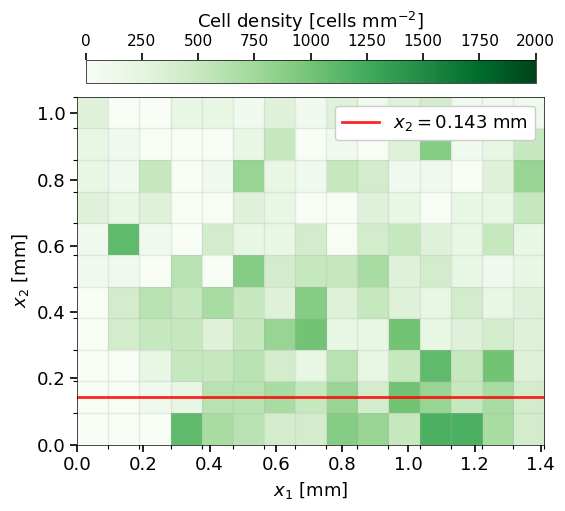

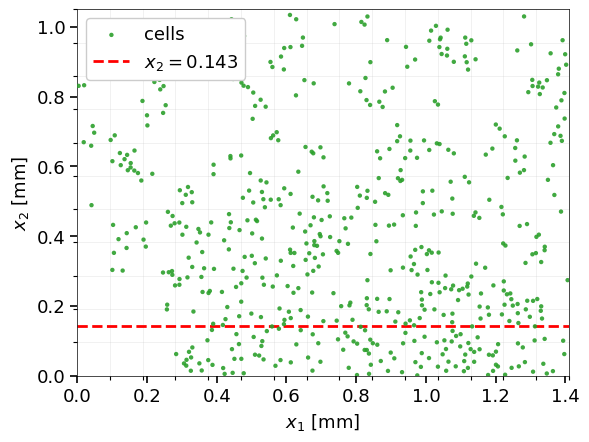

[2_5] Saved heatmap: outputs/figures/supplement/x4_2_x5_5/density_heatmap_slice_green_t0000.png
[2_5] Saved scatter: outputs/figures/supplement/x4_2_x5_5/positions_scatter_t0000.png
Processing key: 2_3


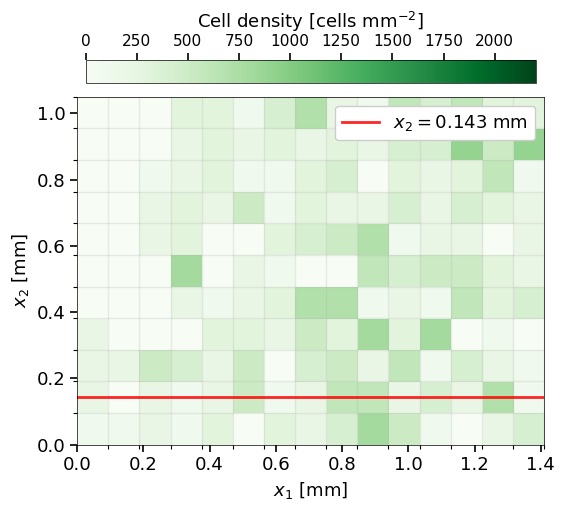

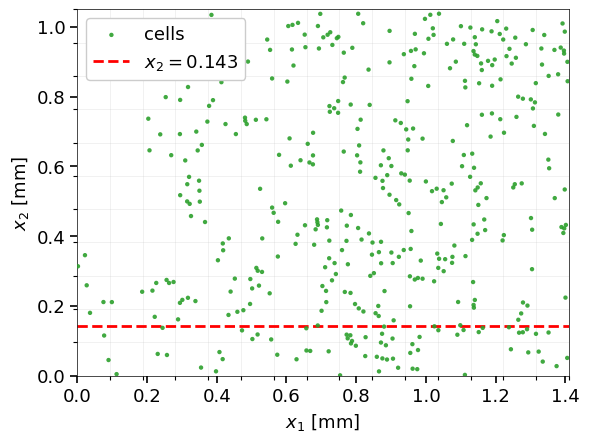

[2_3] Saved heatmap: outputs/figures/supplement/x4_2_x5_3/density_heatmap_slice_green_t0000.png
[2_3] Saved scatter: outputs/figures/supplement/x4_2_x5_3/positions_scatter_t0000.png
Processing key: 3_1


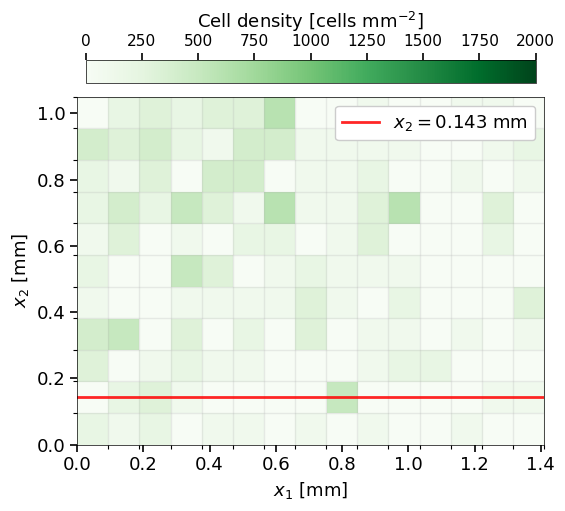

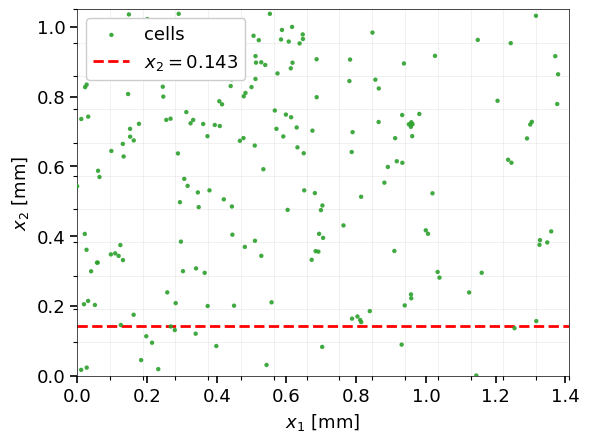

[3_1] Saved heatmap: outputs/figures/supplement/x4_3_x5_1/density_heatmap_slice_green_t0000.png
[3_1] Saved scatter: outputs/figures/supplement/x4_3_x5_1/positions_scatter_t0000.png


In [24]:
# ==============================
# Data visualization by replicate
# ==============================

for key in keys:
    print(f"Processing key: {key}")

    # Retrieve replicate-specific metadata and data object
    data_info = dataInfo_dict[key]
    x4opt_save = data_info["x4opt"]
    x5opt_save = data_info["x5opt"]
    data_obj = dataObj_dict[key]

    # Create a dedicated output directory for this replicate/parameter combination
    save_path = os.path.join(FIGURES_SUPP_DIR, f"x4_{x4opt_save}_x5_{x5opt_save}")
    os.makedirs(save_path, exist_ok=True)

    # Initialize plotting helper
    plotter = DensitySnapshotPlotter(
        out_dir=save_path,
        overwrite_existing=True,
        show=True,
        save_dpi=100,
    )

    # Generate paired density-heatmap and scatter snapshots at the selected time index
    heat_png, scatter_png = plotter.make_density_heatmap_and_scatter_snapshots(
        data_obj=data_obj,
        ix=None,
        iy=1,
        species=speciesLabel,
        t_index=0,
        figsizes=((6, 5), (6, 5)),
        legend_fontsize=13,
        legend_loc_heatmap="upper right",
        legend_loc_scatter="upper left",
        xlabel_fontsize=13.0,
        ylabel_fontsize=13.0,
        xtick_labelsize=13,
        ytick_labelsize=13,
        title_fontsize=11,
        major_tick_length=5.0,
        major_tick_width=1.2,
        minor_tick_length=3.0,
        minor_tick_width=0.8,
        legend_kwargs={"framealpha": 1},
        cbar_label_fontsize=13.0,
        cbar_tick_fontsize=11,
        cbar_shrink=0.8,
        cbar_fraction=0.1,
    )

    print(f"[{key}] Saved heatmap: {heat_png}")
    print(f"[{key}] Saved scatter: {scatter_png}")

## Time-aligned vs relative-time scatter analyses

This block generates two complementary multi-replicate scatter products:

1. **Absolute-time snapshots** (`make_green_cell_scatter_snapshots_for_times_with_keys_as_subplots`): compares replicates at matched absolute experimental time.
2. **Relative-time snapshots** (`make_green_cell_scatter_snapshots_for_relative_times_with_keys_as_subplots`): aligns each replicate by its own baseline time and is used to identify the parameter **$\tau$**.

The relative-time alignment output is the diagnostic basis for selecting $\tau$, which is then used to choose specific time points for **Appendix B**.

In [25]:
# Since paper does not use the plots outputted directly this code is commented out.

# # Compare replicate scatter snapshots at matched absolute times
# saved_by_time = plotter.make_green_cell_scatter_snapshots_for_times_with_keys_as_subplots(
#     data_obj_dict=dataObj_dict,
#     keys=keys,
#     time_array=range(4, 64 + 1, 4),
#     ix=None,
#     iy=1,
#     show_slice_lines=True,
#     figsize_per_panel=(4.5, 4.0),
#     mapping_dict={"2_5": "repl.1", "2_3": "repl.2", "3_1": "repl.3"},
# )

# # Align by replicate-specific baseline time to support tau selection
# saved_by_time_rel = plotter.make_green_cell_scatter_snapshots_for_relative_times_with_keys_as_subplots(
#     data_obj_dict=dataObj_dict,
#     keys=keys,
#     relative_time_array=range(0, 60 + 1, 4),  # hours after each replicate-specific t0
#     ix=None,
#     iy=1,
#     show_slice_lines=True,
#     figsize_per_panel=(4.5, 4.0),
#     mapping_dict={"2_5": "repl.1", "2_3": "repl.2", "3_1": "repl.3"},
#     highlight_dense_squares=True,
#     density_threshold=1000.0,
# )

These relative-time selected snapshots are subsequently reused to construct Fig. 7 in **Appendix B**. The next cell (`make_green_cell_scatter_snapshots_individually_for_keys_and_times`) produces these plots.

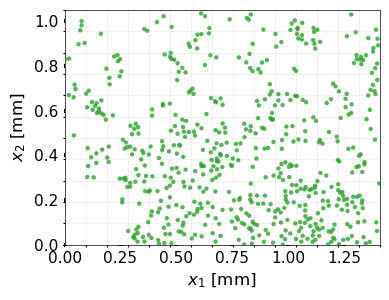

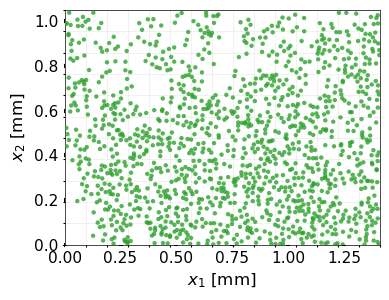

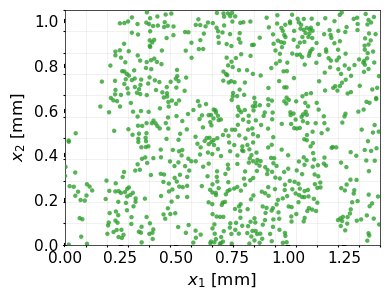

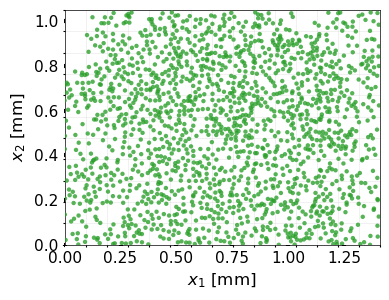

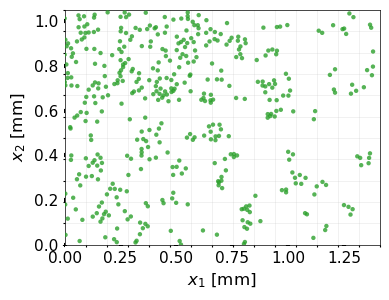

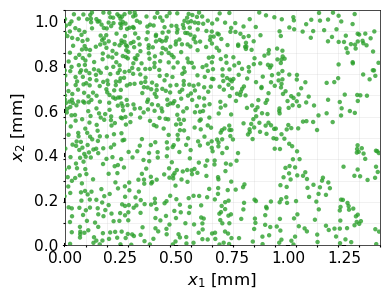

2_5 24.0 -> outputs/figures/supplement/x4_3_x5_1/per_key_individual_times/green_cell_scatter_key_2_5__req_24p0h__used_24h.png
2_5 48.0 -> outputs/figures/supplement/x4_3_x5_1/per_key_individual_times/green_cell_scatter_key_2_5__req_48p0h__used_48h.png
2_3 24.0 -> outputs/figures/supplement/x4_3_x5_1/per_key_individual_times/green_cell_scatter_key_2_3__req_24p0h__used_24h.png
2_3 48.0 -> outputs/figures/supplement/x4_3_x5_1/per_key_individual_times/green_cell_scatter_key_2_3__req_48p0h__used_48h.png
3_1 24.0 -> outputs/figures/supplement/x4_3_x5_1/per_key_individual_times/green_cell_scatter_key_3_1__req_24p0h__used_24h.png
3_1 48.0 -> outputs/figures/supplement/x4_3_x5_1/per_key_individual_times/green_cell_scatter_key_3_1__req_48p0h__used_48h.png


In [26]:
# Generate per-time, per-replicate scatter panels for Appendix B figure assembly
saved = plotter.make_green_cell_scatter_snapshots_individually_for_keys_and_times(
    data_obj_dict=dataObj_dict,
    keys=keys,
    time_array=[24, 48],
    ix=None,
    iy=1,
    show_slice_lines=False,
    xlabel_fontsize=12.0,
    ylabel_fontsize=12.0,
    xtick_labelsize=11,
    ytick_labelsize=11,
    title_fontsize=0,
    major_tick_length=1.0,
    major_tick_width=3,
    minor_tick_length=1.5,
    minor_tick_width=0.8,
)

for key, time_map in saved.items():
    for req_t, path in time_map.items():
        print(key, req_t, "->", path)

## Choose and load BINN models

This blocks reconstructs the trained BINN ensembles by replicate, early-stopping horizon, and train-validation split seed. Structured dictionaries store the models selected that are reused by prediction, loss, SR, and forward-simulation sections.

In [27]:

# ============================================================
# SETUP PATHS
# ============================================================
initial_path = os.path.join("../binn_v2_models")
binn_df = paths_to_df(
    find_data_obj_files(start_dir=initial_path, target_filename="binnModel0.pth")
)

# Optional: containers for filtered BINN dfs per replicate
binn_df_by_key = {}


# ============================================================
# FIXED BINN HYPERPARAMETERS
# ============================================================
binnBatchSize = 38
binnRelSaveThresh = 0.05
binnRelUpdateThresh = 0.05
binnLR = 1e-3

binn_split_seed = 0
binnDevice = "cpu"

BNdataLossFuncLabel = "MSE"
BCbool = 0

u_NN = 64
D_NN = 4
G_size = 4

DoneParamBool = False

numPDEsamples = 100


# ============================================================
# USER PARAMETERS
# ============================================================
binn_ES = 500
binnVF = 0.2
binn_model_num = 0

binnSplitSeeds = np.arange(5)
denoise_model_num = 0

D_bound = 1
D_constraint_bool = 0
allConstraints = 0

# Save updated models after rebasing once; set False for read-only behavior.
persist_rebased_paths = True

# ============================================================
# EXPERIMENT SETTINGS
# ============================================================
binn_ES_list = [500, 1000, 2000]

binn_models_dics_ES = {}
binn_exts = {}



# ============================================================
# MAIN LOOP OVER ES VALUES
# ============================================================
for ES in binn_ES_list:
    binn_models_dics_ES[ES] = {}
    binn_exts[ES] = {}

    # --------------------------------------------------------
    # LOOP OVER REPLICATE KEYS
    # --------------------------------------------------------
    for key in keys:
        # --- Metadata ---
        speciesLabel = speciesLabels[key]
        x2opt = x2opts[key]
        x3opt = x3opts[key]
        x4opt = x4opts[key]
        x5opt = x5opts[key]
        hoursRange = hoursRanges[key]

        xmin, xmax = xmins[key], xmaxs[key]
        ymin, ymax = ymins[key], ymaxs[key]
        dx, dy = dxs[key], dys[key]

        # --- Optional filtering ---
        binn_df_by_key[key] = condense_df(
            binn_df.copy(),
            dataInfo_dict[key]
        )

        # Initialize containers
        binn_models_dics_ES[ES][key] = {}
        binn_exts[ES][key] = {}

        # ----------------------------------------------------
        # BASE CONFIGURATION DICTIONARY
        # ----------------------------------------------------
        base_binn_ext = {
            "speciesLabel": speciesLabel,
            "x2opt": x2opt,
            "x3opt": x3opt,
            "x4opt": x4opt,
            "x5opt": x5opt,
            "x7": x7,
            "dx": dx,
            "dy": dy,
            "xmin": xmin,
            "ymin": ymin,
            "xmax": xmax,
            "ymax": ymax,
            "hoursRange": list(hoursRange),

            # Model params
            "gamma": gamma,
            "K": K,
            "binnVF": binnVF,

            # Data split / architecture
            "binnGenerateIndicesLabel": "random",
            "binnTVsplitSeed": binnSplitSeeds[0],
            "binnUsize": u_NN,
            "binnDsize": D_NN,
            "binnGsize": G_size,

            # Flags
            "DoneParamBool": DoneParamBool,
            "binnDevice": binnDevice,
            "allConstraints": allConstraints,
            "D_constraint_bool": D_constraint_bool,
            "D_bound": D_bound,

            # Loss / BC
            "BNdataLossFuncLabel": BNdataLossFuncLabel,
            "BCbool": BCbool,

            # Training
            "numPDEsamples": numPDEsamples,
            "binnLR": binnLR,
            "binnBatchSize": binnBatchSize,
            "binnRelUpdateThresh": binnRelUpdateThresh,
            "binnRelSaveThresh": binnRelSaveThresh,
            "binnES": ES,

            # Misc
            "binnModelLabel": binn_model_num,
        }
        

        # ----------------------------------------------------
        # LOOP OVER SPLIT SEEDS
        # ----------------------------------------------------
        for binnSplitSeed in binnSplitSeeds:
            binn_ext = copy.deepcopy(base_binn_ext)
            binn_ext["binnTVsplitSeed"] = binnSplitSeed

            # Resolve the model path from discovered files instead of rebuilding
            # the full directory string manually. Only filter on columns that
            # exist in binn_df, because some metadata keys may be absent.
            match_info = {k: v for k, v in binn_ext.items() if k in binn_df.columns}
            matched = condense_df(binn_df.copy(), match_info)
            if matched.empty:
                raise FileNotFoundError(
                    f"No model match for key={key}, ES={ES}, split={binnSplitSeed}, "
                    f"model={binn_model_num}"
                )

            file_path = matched["full_path"].iloc[0]

            # --- Load model ---
            binn_loaded = torch.load(file_path, weights_only=False)
            
            # Fix paths inside model relative to cwd
            binn_loaded.load_best_val()

            # Persist updated save_name and best-val state so rebasing is one-time.
            # if persist_rebased_paths:
            #     torch.save(binn_loaded, file_path)

            # --- Store ---
            binn_models_dics_ES[ES][key][binnSplitSeed] = binn_loaded
            binn_exts[ES][key][binnSplitSeed] = binn_ext
            


# ============================================================
# SELECT SPECIFIC ESSor
# ============================================================
ES = 500
binn_models_dics = binn_models_dics_ES[ES]
binn_models_dics1000 = binn_models_dics_ES[1000]

### Plotting styles for plots in the paper

This styling block enforces a consistent visual coordination across manuscript figures.

In [28]:
## Colour schemes for surrogates

uMLP_colours = [ 
    "#0033A0", 
    "#1E90FF", 
    "#6699CC", 
    "#A4C8E1", 
    "#D6EAF8" 
]


DMLP_colors = [
        "#8B2500",  # Burnt Orange – deep and bold
        "#FF7F0E",  # Vivid Orange – saturated, readable, classic plot color
        "#FDB863",  # Soft Tangerine – warm midtone
]

GMLP_colors = [
    "#00441B",  # Deep Forest Green – dark, bold
    "#1A9850",  # Vivid Green – saturated, classic "plot green"
    "#66C2A4",  # Soft Mint Green – pleasant midtone
]

## Legend styles
def form_labels(keys):
    labels = []
    for key in keys:
        keys = key.split("_")
        label = f"Replicate ({keys[0]},{keys[1]})"
        labels.append(label)
    return labels


linestyles = ['-']*5
marker_styles = ['o']*5

## density plot styling
plot_params = {
    str(es): [uMLP_colours[i], linestyles[i], marker_styles[i], str(es)]
    for i, es in enumerate(binn_ES_list)
}

## Density predictions
Density surrogate predictions for fixed $x_1$/$x_2$ cross-sections.

- **Paper Reference**: fixed $x_2$ cross-section corresponds to **Fig. 6(c),(d)** in the paper.

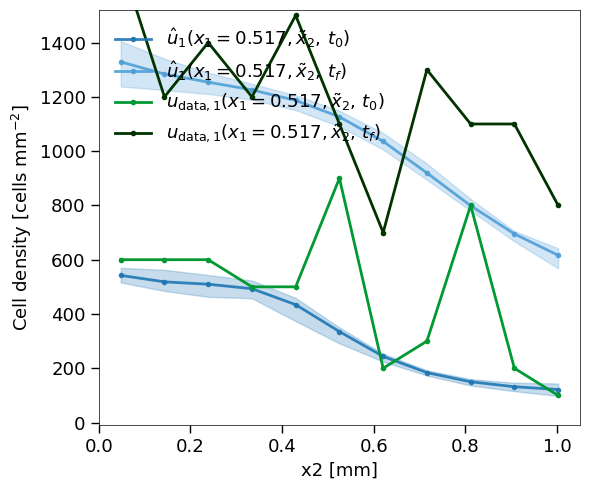

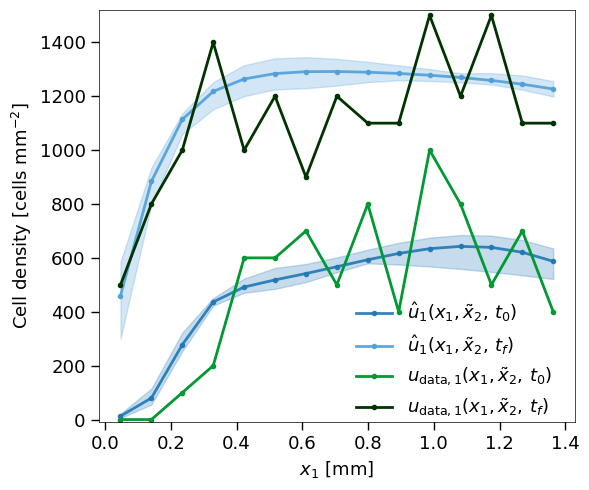

In [29]:
# =======================================================================================
# For chosen replicate plotting density slices at t=0,T and fixed x1 & x2 slices
# =======================================================================================

plotter = MidlinePlotter(device="cpu")
chosen_key2 = "2_5"
x1_idx = 5
x2_idx = 1
x4opt_save = 2
x5opt_save = 5
chosen_key2 = f"{x4opt_save}_{x5opt_save}"

# Match the same figures/main folder style used by other main plots
midline_base_dir = os.path.join(
    FIGURES_MAIN_DIR,
    f"key_{chosen_key2}_x4_{x4opt_save}_x5_{x5opt_save}",
)

_ = plotter.plot_midline_prediction_vs_data(
    model_wrappers=binn_models_dics[chosen_key2],
    dataobj=dataObj_dict[chosen_key2],
    species_label=speciesLabel,
    K=1,
    save_name="data_and_u_hat.png",
    save_dic={},
    base_dir=midline_base_dir,
    overwrite=True,
    legend_fontsize=13,
    legend_ncols=1,
    figsize=(6, 5),
    legend_loc_x1=(0.525, -0.01),
    x1_idx=x1_idx,
    x2_idx=x2_idx,
    xlabel_fontsize=13,
    ylabel_fontsize=13,
    xtick_labelsize=13,
    ytick_labelsize=13,
    tick_length=6,
    tick_width=1,
    minor_tick_length=3,
    ylim = [-10,1520],
    minor_tick_width=0.0)




## Evolution of learned diffusion and growth with epochs
Figures used as to inspect convergence behavior and mechanism plausibility.
- **Paper reference**: Plots form Fig 6 (c)-(d).

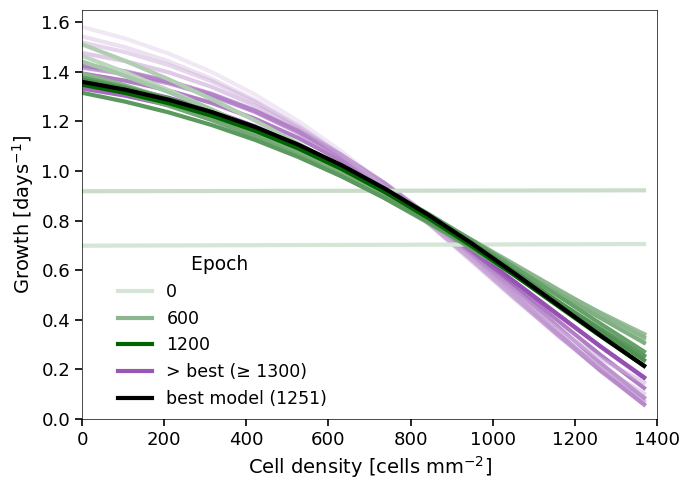

Saved growth plot for 2_5, model_index=0: outputs/figures/main/key_2_5_x4_2_x5_5/DGgif_growth_2_5_model0.png


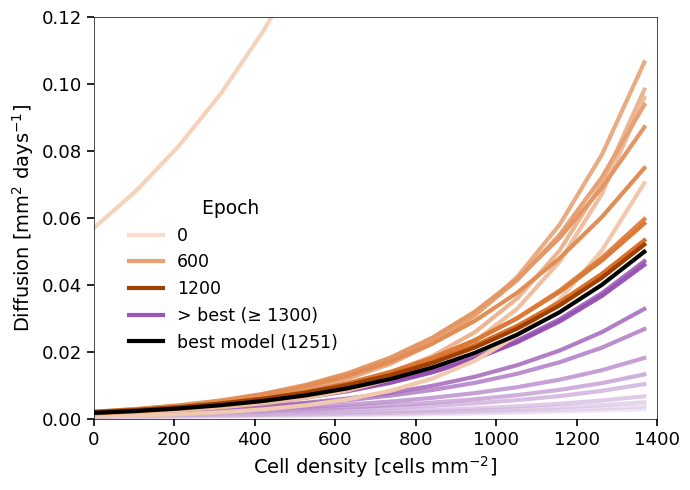

Saved diffusion plot for 2_5, model_index=0: outputs/figures/main/key_2_5_x4_2_x5_5/DGgif_diffusion_2_5_model0.png


In [30]:
plotter = TrainingDynamicsPlotter(
    device="cpu",
    gray_base_color="#8E44AD",
)

chosen_key2 = "2_5"
chosen_TV = 3  # 0,1,2,3,4

save_path1 = os.path.join(FIGURES_MAIN_DIR, f"key_{chosen_key2}_x4_{x4opt_save}_x5_{x5opt_save}")

plotter.plot_single_run_growth_diffusion_over_training(
    model_wrapper_groups={chosen_key2: {chosen_TV: binn_models_dics1000[chosen_key2][chosen_TV]}},
    dataobj=dataObj_dict[chosen_key2],
    species_label=speciesLabel,
    save_dic={},
    base_dir=save_path1,
    save_name="DGgif.gif",
    labels=form_labels(keys),
    num_bins=50,
    K=1,
    figsize=(7, 5),
    legend_pos_diffusion=(0.05, 0.15),
    legend_pos_growth=(0.05, 0.01),
    legend_fontsize=12.5,
    legend_ncols=1,
    axis_labels=True,

    # New explicit axis/tick styling
    xlabel_fontsize=14,
    ylabel_fontsize=14,
    xtick_labelsize=13,
    ytick_labelsize=13,
    major_tick_length=5.0,
    major_tick_width=1.2,
    minor_tick_length=3.0,
    minor_tick_width=0.8,

    overwrite=True,
    y_lim_growth=[0.0, 1.65],
    y_lim_diffusion=[0, 0.12],
    model_index=0,
    x_lim=[0, 1400],
    save_dir2=None,
    epoch_step=10,
    epochs_sf=10,
)

## Validation loss and learning time
The total validation loss and learning time for all the BINN models (for a specified replicate).
- **Paper reference**: Printed output forms Table III when one loops over replicates.


Selected replicate 2 | key = 2_3
Configurations loaded:
  ES = 500        | runs = 5
  ES = 1000       | runs = 5
  ES = 2000       | runs = 5

Validation loss and total learning time summary

--- Summary ---
            500 | val loss: mean=0.01305, range=[0.01248, 0.01337] | time: mean=152.8 s, range=[133, 172.7] s
           1000 | val loss: mean=0.01267, range=[0.01122, 0.01337] | time: mean=300.2 s, range=[186.6, 413.8] s
           2000 | val loss: mean=0.01225, range=[0.01122, 0.01266] | time: mean=591.7 s, range=[525, 658.4] s



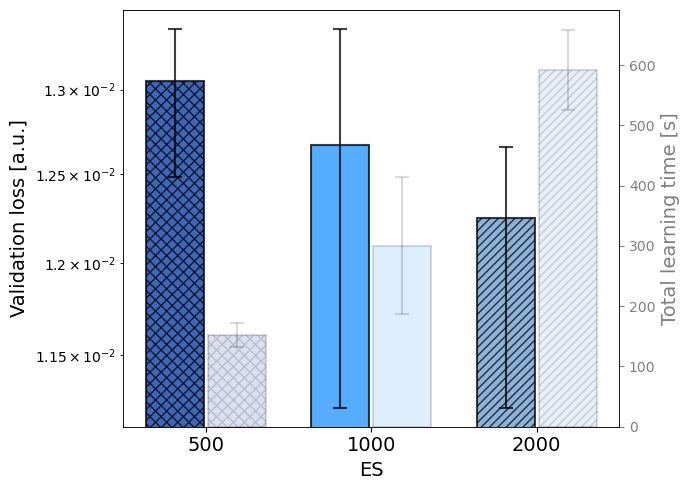

In [31]:
# =======================================================================================
# For chosen replicate plot & print final validation loss and total learning time
# =======================================================================================
key = "2_3"

binn_models_combined = {
    str(ES): binn_models_dics_ES[ES][key]
    for ES in binn_ES_list
    if key in binn_models_dics_ES[ES]
}

summary_plotter = TrainingSummaryPlotter()

# ---- choose replicate index ----
chosen_index2 = 1
chosen_key2 = keys[chosen_index2]

print("\n" + "=" * 100)
print(f"Selected replicate {chosen_index2 + 1} | key = {key}")
print("=" * 100)

print("Configurations loaded:")
for es, model_dict in binn_models_combined.items():
    print(f"  ES = {es:<10} | runs = {len(model_dict)}")

# ---- plot ----
summary_plotter.plot_loss_and_runtime_summary(
    models_dics_list=[binn_models_combined],
    plot_params=plot_params,
    label_list=["Summary"],
    hatch_patterns=("xxx", "", "////", "\\\\", "xxxx", "++++", "....", "ooo"),
    name=None,  # or name_full
    intra_spacing=0.15,
    inter_spacing=0.40,
    legend_bool=False,
    figsize=(7, 5),
    x_label=r"ES",
    y2_label="Total learning time [s]",
    alpha=0.15,
    print_summary=True,
    print_precision=4,
)

## Loss histories
Plots for the total validation loss as well the data and PDE loss breakdown.


- **Paper reference**: The data loss and PDE loss form **Figs 6 (a)** and **(b)** respectively.

Total loss trajectories for 2_5


/Users/willa954/Desktop/Git-public/pinn-reaction-diffusion-2dt/main/JN/paper_helpers/plotting/loss_trajectories.py:393: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


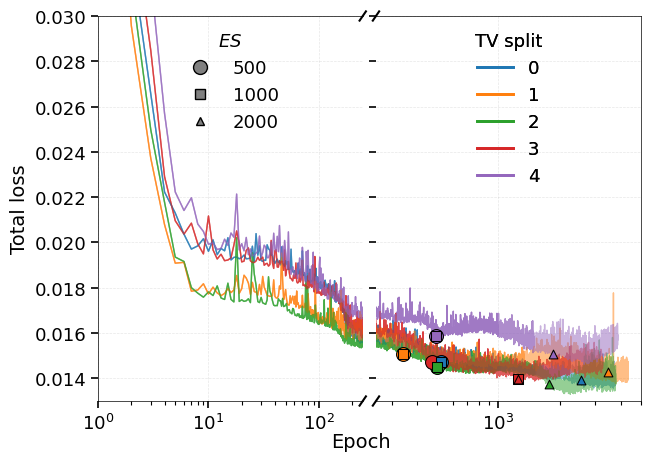

Data loss trajectories for 2_5


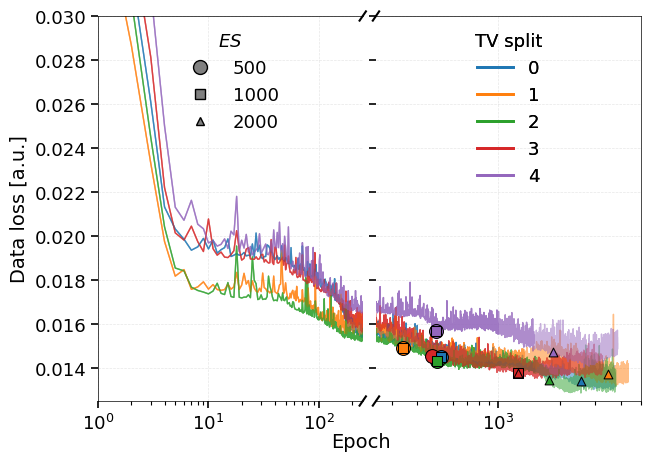

PDE loss trajectories for 2_5


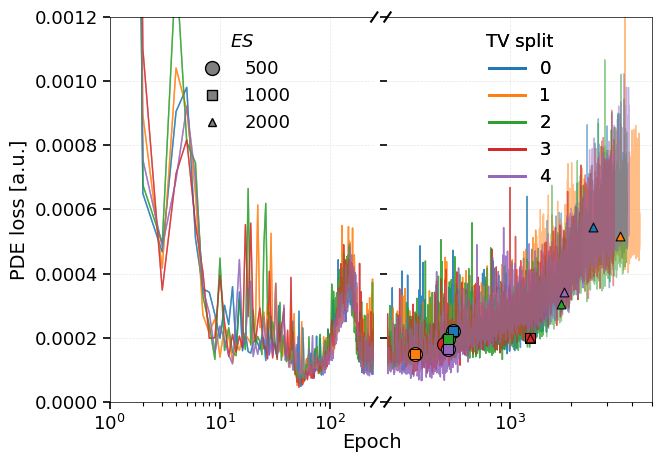

In [32]:
# =========================================================================================
# Plot PDE and data losses across replicates for each ES \in [500,1000,2000]
# =========================================================================================

chosen_key3 = "2_5"
es_plotter = EarlyStoppingTrajectoryPlotter()

es_plotter.plot_loss_trajectories_across_early_stopping(
    models_dics_list=[{chosen_key3: binn_models_dics_ES[es][chosen_key3]} for es in binn_ES_list],
    es_list=binn_ES_list,
    use_val_loss=True,
    yscale=None,
    xscale="log",
    ylim_total=(1.3e-2, 3e-2),
    ylim_data=(1.25 * 1e-2, 3e-2),
    ylim_pde=(0, 1.2e-3),
    xlim_left=(1, 250),
    xlim_right=(250, 5000),
    figsize=(7, 5),
    base_cmap="Blues",
    es_marker_map=None,
    title=None,
    base_dir=save_path1,

    # Axis/tick styling
    xlabel_fontsize=14,
    ylabel_fontsize=14,
    xtick_labelsize=13,
    ytick_labelsize=13,
    major_tick_length=5.0,
    major_tick_width=1.2,
    minor_tick_length=3.0,
    minor_tick_width=0.8,

    # Legend placement
    total_legend_loc_repeat="upper center",
    total_legend_loc_es="upper center",
    data_legend_loc_repeat="upper center",
    data_legend_loc_es="upper center",
    pde_legend_loc_repeat="upper center",
    pde_legend_loc_es="upper center",

    # Legend font sizes: total-loss panel
    total_repeat_legend_fontsize=13,
    total_repeat_legend_title_fontsize=13,
    total_es_legend_fontsize=13,
    total_es_legend_title_fontsize=13,

    # Legend font sizes: data-loss panel
    data_repeat_legend_fontsize=13,
    data_repeat_legend_title_fontsize=13,
    data_es_legend_fontsize=13,
    data_es_legend_title_fontsize=13,

    # Legend font sizes: PDE-loss panel
    pde_repeat_legend_fontsize=13,
    pde_repeat_legend_title_fontsize=13,
    pde_es_legend_fontsize=13,
    pde_es_legend_title_fontsize=13,
)

## Symbolic diffusion discovery

This section converts diffusion MLP outputs to symbolic outputs via `PySR`

- **Paper reference**: The second cell (begins with `#TABULATE`) is used to print all candidate expressions for each replicate. This information is used to form diffusion components of Table II and Table IV.


[1/3] key=2_5
Checking file existence for this case...
Loading from outputs/sr/speciesLabel_green/x2opt_0p0/x3opt_0p0/x4opt_2/x5opt_5/x7_1/dx_100.0/dy_100.0/xmin_0.0/ymin_0.0/xmax_1410.0/ymax_1050.0/hoursRange_[24, 28, 32, 36, 40, 44, 48, 52, 56]/gamma_0/K_1/binnVF_0.2/binnGenerateIndicesLabel_random/binnTVsplitSeed_4/binnUsize_64/binnDsize_4/binnGsize_4/DoneParamBool_False/binnDevice_cpu/allConstraints_0/D_constraint_bool_0/D_bound_1/BNdataLossFuncLabel_MSE/BCbool_0/numPDEsamples_100/binnLR_0.001/binnBatchSize_38/binnRelUpdateThresh_0.05/binnRelSaveThresh_0.05/binnES_500/binnModelLabel_0/diff_SR_densityScalingdimensionless_yScalingdimensionless_predSFTrue_pop50_con{}_maxsize10_parsimony0_model_selectionbest_niter25_percentiles[5, 95]_seeds[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]_loss(x - y)^2_ops['log', 'exp', 'sqrt'].pkl...

[1/3] key=2_5
LOAD took 00:00:00 | Elapsed: 00:00:00 | ETA: 00:00:00 (estimated remaining: 2.0 load, 0.0 compute)
Scaling: density_scaling=dimensionless, y_scaling=dimens

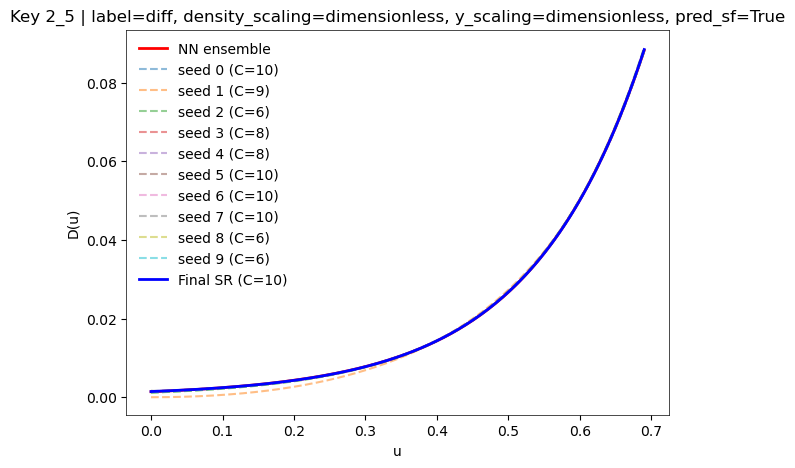

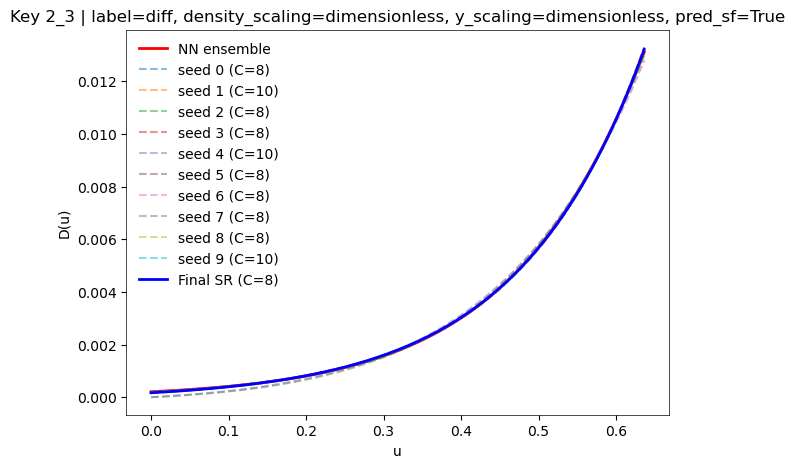

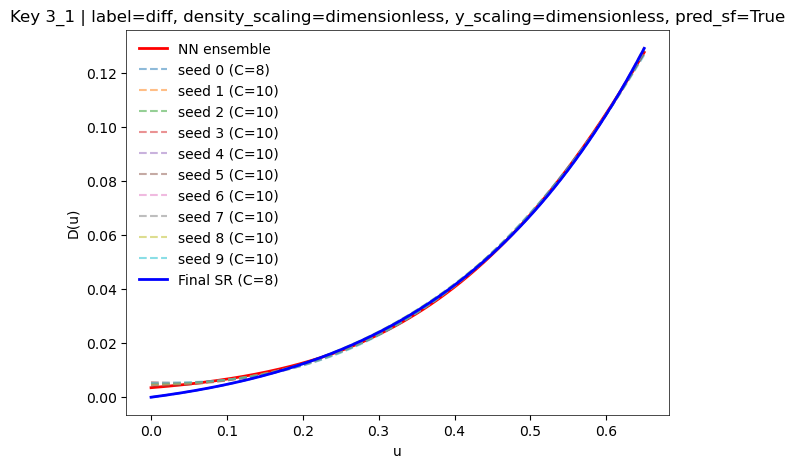

In [33]:
# --- SR Infrastructure & Scaling ---
SR_device          = "cpu"
SR_yscaling        = "dimensionless"
SR_density_scaling = "dimensionless"

# --- Evolution & Search Space ---
SR_niter           = 25
SR_seeds           = range(10)
SR_pop_size        = 50 
SR_max_size        = 10
SR_parsimony       = 0
SR_percentiles     = [5, 95]
ES = 500


# --- Math & Objectives ---
SR_loss            = "(x - y)^2"
SR_unary_ops       = ["log", "exp", "sqrt"]
SR_binary_ops      = ["+", "-", "*", "/"]
SR_constraints     = {}
SR_model_selection = "best"

# --- Logging & Flags ---
SR_verbose         = 1
SR_use_sf          = True

# --- The Runner Initialization ---
runner_diff = SymbolicRegressionBatchRunner(
    label=                  "diff",
    keys=                   keys,
    dataObj_dict=           dataObj_dict,
    binn_models_dics_ES=    binn_models_dics_ES,
    binn_exts=              binn_exts,
    ES=                     ES,
    binnSplitSeeds=         binnSplitSeeds,
    build_save_base=        build_save_base,
    # Variable Mappings:
    device=                 SR_device,
    density_scaling=        SR_density_scaling,
    y_scaling=              SR_yscaling,
    use_sf_for_predictions= SR_use_sf,
    population_size=        SR_pop_size,
    percentiles=            SR_percentiles,
    niter=                  SR_niter,
    seeds=                  SR_seeds,
    loss=                   SR_loss,
    unary_operators=        SR_unary_ops,
    binary_operators=       SR_binary_ops,
    constraints=            SR_constraints,
    maxsize=                SR_max_size,
    parsimony=              SR_parsimony,
    model_selection=        SR_model_selection,
    verbose=                SR_verbose,
    base_dir=               SR_OUTPUT_DIR
)


# run without plotting
runner_diff.run(plot=False)

# plot later
runner_diff.plot_runs()

# or do both in one call
# runner.run(plot=True)

results_diff = runner_diff.get_results()
D_SR_runs = results_diff["D_SR_runs_by_key"]


In [34]:
#TABULATE 

reporter_diff = SymbolicRegressionSeedReporter(
    SR_runs=D_SR_runs,
    keys=keys,
    label = "diff",
)

# 1. Print summaries and build rankings
results_by_key = reporter_diff.analyze(verbose=True)

# 2. Count forms
global_form_counts = reporter_diff.expression_form_counts(
    include_excluded=False,
    per_key=False,
    verbose=True,
)

per_key_form_counts = reporter_diff.expression_form_counts(
    include_excluded=False,
    per_key=True,
    verbose=True,
)

# 3. NEW: Best expression within each form, based on ordinary MSE
global_best_per_form = reporter_diff.best_expression_per_form(
    include_excluded=False,
    per_key=False,
    sort_by="count",   # or "mse"
    verbose=True,
)

per_key_best_per_form = reporter_diff.best_expression_per_form(
    include_excluded=False,
    per_key=True,
    sort_by="count",   # or "mse"
    verbose=True,
)

# # 4. Plot raw-space fits and residuals
# reporter_diff.plot_runs()

# # 5. Optional structured summary
# summary_diff = reporter_diff.global_summary()
# print(summary_diff)


CLEANED D SYMBOLIC EXPRESSIONS & WEIGHTED-FIT RANKING

>>> KEY: 2_5
    Excluding seeds from stats: []
  [Seed  0] D(x0) = 0.0011097733022936*exp(6.3390927*x0) + 0.000338390420298546
  [Seed  1] D(x0) = -0.05065054*x0**2/(1.0*x0 - 0.96327764)
  [Seed  2] D(x0) = 0.0011466517*exp(6.3069572*x0)
  [Seed  3] D(x0) = 0.0011593666*exp(6.273767*x0) + 0.0001714498
  [Seed  4] D(x0) = 0.0011752639*exp(6.2534194*x0) + 0.00011879827
  [Seed  5] D(x0) = 0.0011359175*exp(6.304294*x0) + 0.0002499186
  [Seed  6] D(x0) = 0.00114732752049081*exp(6.289362*x0) + 0.00021161615
  [Seed  7] D(x0) = 0.0016803568*exp(-1.0*sqrt(x0) + 6.9485407*x0)
  [Seed  8] D(x0) = 0.00117675017199759*exp(6.2550135*x0)
  [Seed  9] D(x0) = 0.0011880185*exp(6.2400837*x0)

  --- Final Ranked Seeds (Best to Worst Weighted Fit) ---
    Rank  1: Seed  0 | W-MSE: 8.3944e-10 | MSE: 1.3702e-09 | Runtime: 20.9 s | Expr: 0.0011097733022936*exp(6.3390927*x0) + 0.000338390420298546
    Rank  2: Seed  7 | W-MSE: 2.1672e-09 | MSE: 4.2257e

## Symbolic growth discovery

This section converts growth MLP outputs to symbolic outputs via `PySR`

- **Paper reference**: The second cell (begins with `#TABULATE`) is used to print all candidate expressions for each replicate. This information is used to form growth components of Table II and Table IV.


[1/3] key=2_5
Checking file existence for this case...
Loading from outputs/sr/speciesLabel_green/x2opt_0p0/x3opt_0p0/x4opt_2/x5opt_5/x7_1/dx_100.0/dy_100.0/xmin_0.0/ymin_0.0/xmax_1410.0/ymax_1050.0/hoursRange_[24, 28, 32, 36, 40, 44, 48, 52, 56]/gamma_0/K_1/binnVF_0.2/binnGenerateIndicesLabel_random/binnTVsplitSeed_4/binnUsize_64/binnDsize_4/binnGsize_4/DoneParamBool_False/binnDevice_cpu/allConstraints_0/D_constraint_bool_0/D_bound_1/BNdataLossFuncLabel_MSE/BCbool_0/numPDEsamples_100/binnLR_0.001/binnBatchSize_38/binnRelUpdateThresh_0.05/binnRelSaveThresh_0.05/binnES_500/binnModelLabel_0/grow_SR_densityScalingdimensionless_yScalingdimensionless_predSFTrue_pop50_con{}_maxsize10_parsimony0_model_selectionbest_niter25_percentiles[5, 95]_seeds[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]_loss(x - y)^2_ops['log', 'exp', 'sqrt'].pkl...

[1/3] key=2_5
LOAD took 00:00:00 | Elapsed: 00:00:00 | ETA: 00:00:00 (estimated remaining: 2.0 load, 0.0 compute)
Scaling: density_scaling=dimensionless, y_scaling=dimens

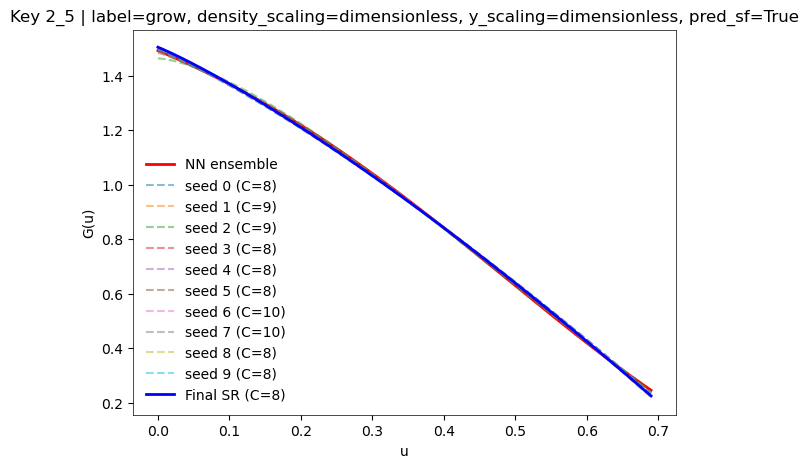

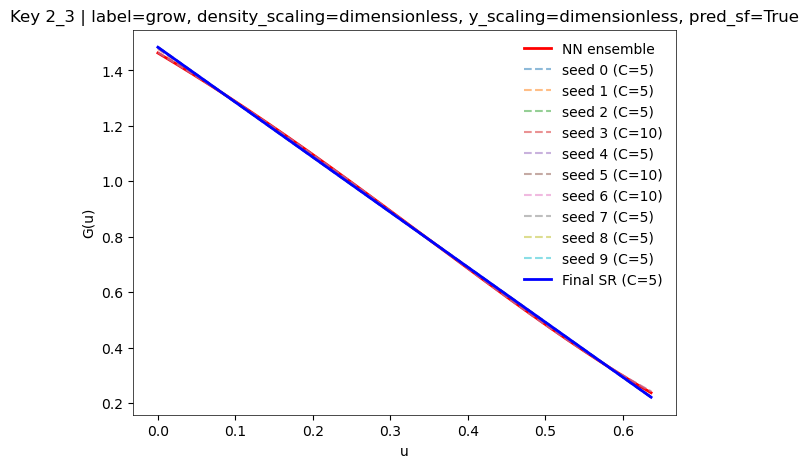

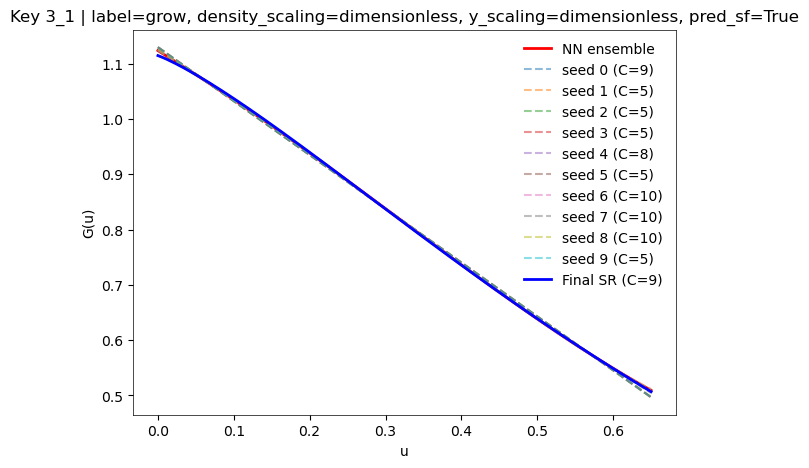

In [35]:
# --- The Runner Initialization ---
runner_grow = SymbolicRegressionBatchRunner(
    label=                  "grow",
    keys=                   keys,
    dataObj_dict=           dataObj_dict,
    binn_models_dics_ES=    binn_models_dics_ES,
    binn_exts=              binn_exts,
    ES=                     ES,
    binnSplitSeeds=         binnSplitSeeds,
    build_save_base=        build_save_base,
    # Variable Mappings:
    device=                 SR_device,
    density_scaling=        SR_density_scaling,
    y_scaling=              SR_yscaling,
    use_sf_for_predictions= SR_use_sf,
    population_size=        SR_pop_size,
    percentiles=            SR_percentiles,
    niter=                  SR_niter,
    seeds=                  SR_seeds,
    loss=                   SR_loss,
    unary_operators=        SR_unary_ops,
    binary_operators=       SR_binary_ops,
    constraints=            SR_constraints,
    maxsize=                SR_max_size,
    parsimony=              SR_parsimony,
    model_selection=        SR_model_selection,
    verbose=                SR_verbose,
    base_dir=               SR_OUTPUT_DIR
)



# run without plotting
runner_grow.run(plot=False)

# plot later
runner_grow.plot_runs()

# or do both in one call
# runner.run(plot=True)

results_grow = runner_grow.get_results()
G_SR_runs = results_grow["G_SR_runs_by_key"]


CLEANED G SYMBOLIC EXPRESSIONS & WEIGHTED-FIT RANKING

>>> KEY: 2_5
    Excluding seeds from stats: []
  [Seed  0] G(x0) = -1.0*x0**(3/2) - 1.0238839*x0 + 1.5041113
  [Seed  1] G(x0) = 1.483197 - 2.0090504*x0**(5/4)
  [Seed  2] G(x0) = -1.3375562 + 2.80070171980855*exp(-1.0*x0**(3/2))
  [Seed  3] G(x0) = -1.0*x0**(3/2) - 1.0*x0 + 1.4958698
  [Seed  4] G(x0) = -1.0*x0**(3/2) - 1.0*x0 + 1.4958694
  [Seed  5] G(x0) = -1.0*x0**(3/2) - 1.0239066*x0 + 1.5041175
  [Seed  6] G(x0) = -1.0294783*x0**(3/2) - 1.0*x0 + 1.5026367
  [Seed  7] G(x0) = -1.0*x0 + 0.48615748 + 1.0*exp(-1.7439846*x0**2)
  [Seed  8] G(x0) = -1.0*x0**(3/2) - 1.0239143*x0 + 1.5041243
  [Seed  9] G(x0) = -1.0*x0**(3/2) - 1.0*x0 + 1.49587

  --- Final Ranked Seeds (Best to Worst Weighted Fit) ---
    Rank  1: Seed  7 | W-MSE: 4.3034e-06 | MSE: 9.2344e-06 | Runtime: 8.7 s | Expr: -1.0*x0 + 0.48615748 + 1.0*exp(-1.7439846*x0**2)
    Rank  2: Seed  2 | W-MSE: 1.8881e-05 | MSE: 3.3734e-05 | Runtime: 6.8 s | Expr: -1.3375562 + 2.8

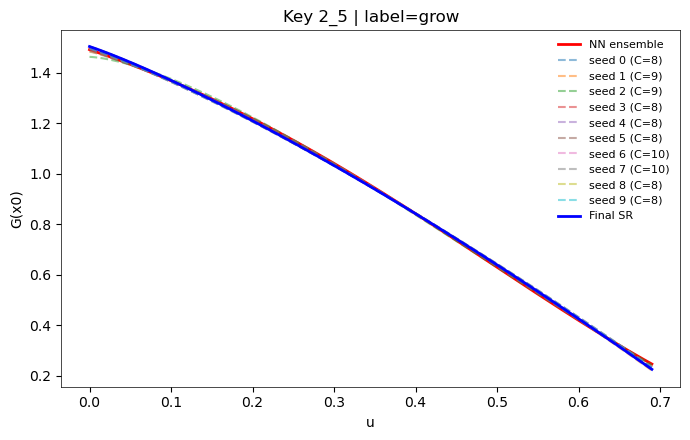

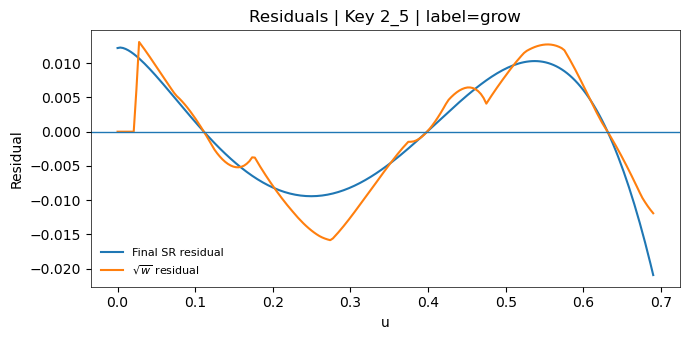

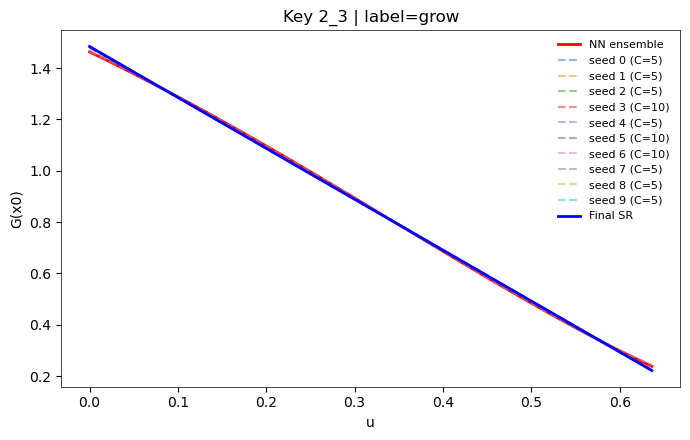

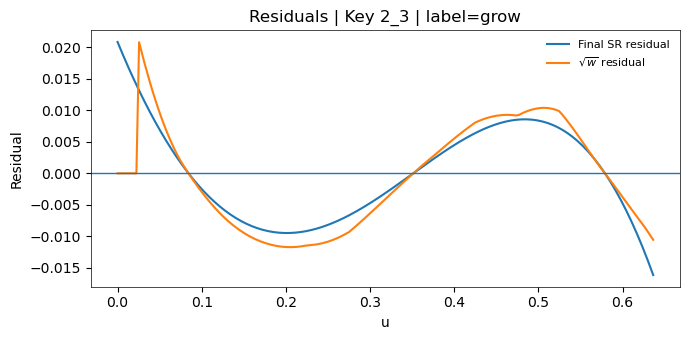

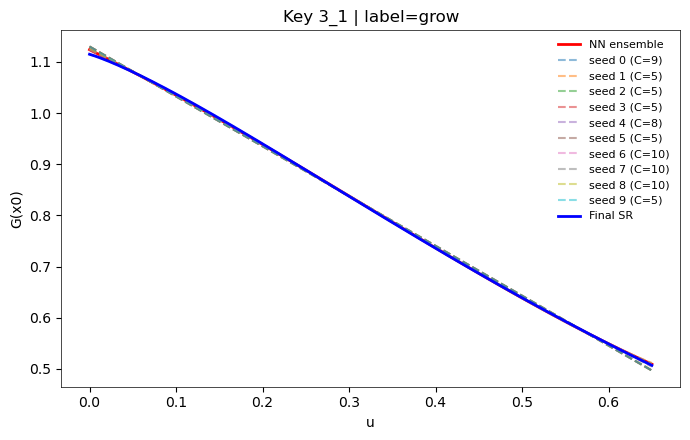

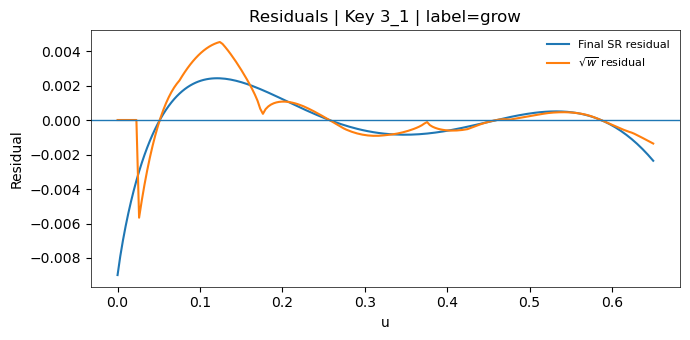

{'all_processed_seeds': '7.7 ± 0.8 s', 'all_kept_seeds': '7.7 ± 0.8 s'}


In [36]:
#TABULATE

reporter_grow = SymbolicRegressionSeedReporter(
    SR_runs=G_SR_runs,
    keys=keys,
    label="grow",
)

# 1. Print summaries and build rankings
results_by_key = reporter_grow.analyze(verbose=True)

# 2. Table of symbolic-expression form counts
global_form_counts_grow = reporter_grow.expression_form_counts(
    include_excluded=False,
    per_key=False,
    verbose=True,
)

per_key_form_counts_grow = reporter_grow.expression_form_counts(
    include_excluded=False,
    per_key=True,
    verbose=True,
)

# 3. Table of best expression per form, where "best" = lowest ordinary MSE
global_best_per_form_grow = reporter_grow.best_expression_per_form(
    include_excluded=False,
    per_key=False,
    sort_by="count",   # or "mse" or "form"
    verbose=True,
)

per_key_best_per_form_grow = reporter_grow.best_expression_per_form(
    include_excluded=False,
    per_key=True,
    sort_by="count",   # or "mse" or "form"
    verbose=True,
)

# 4. Plot raw-space fits and residuals
reporter_grow.plot_runs()

# 5. Optional structured summary
summary_grow = reporter_grow.global_summary()
print(summary_grow)

## Symbolic-vs-neural mechanism comparison

This block instantiates the chosen symbolic candidates (from SR summaries) and compares them against the respective diffusion and growth MLP surrogates.

- **Paper reference**: Histogram, diffusion and growth plots correspond to **Fig. 4 (a)-(c) respectively**

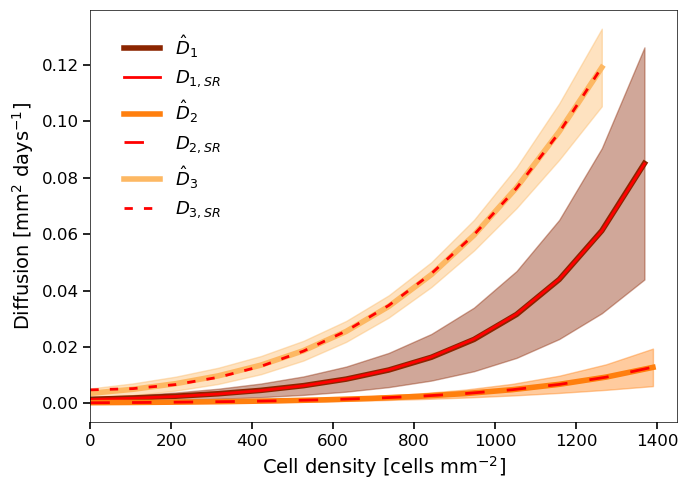

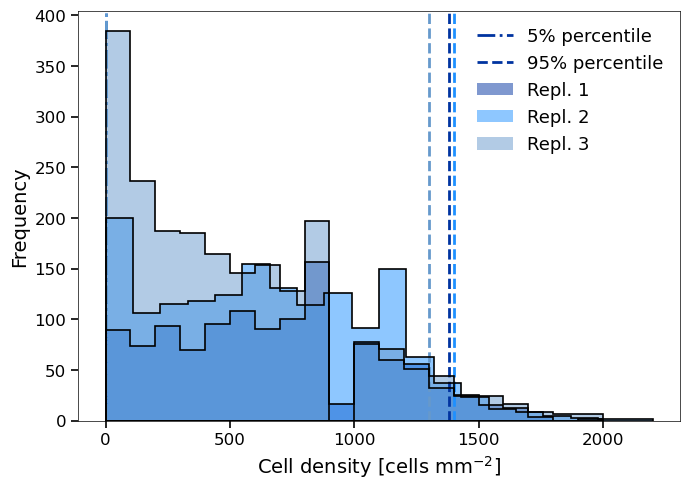

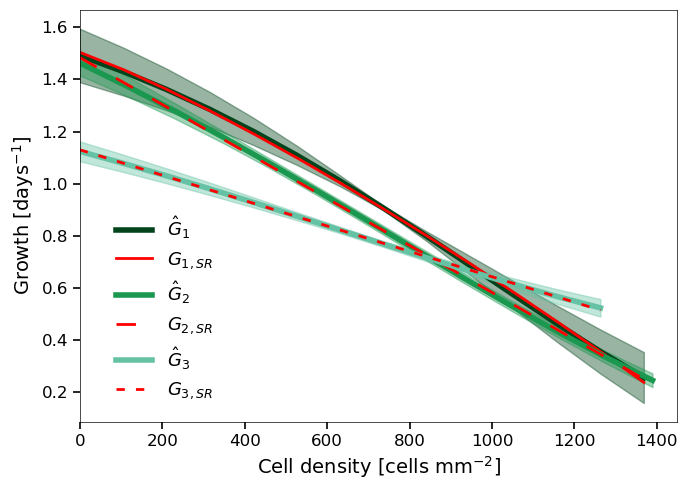

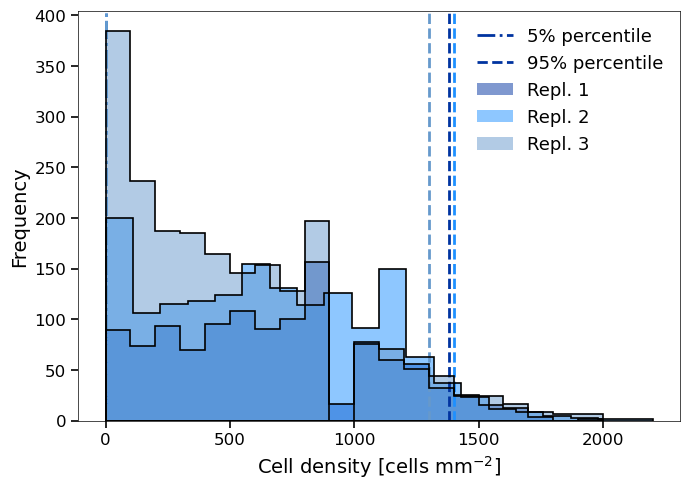

In [37]:
x = sp.Symbol("U")

# ------------------------------------------------------------------
# Symbolic-regression objects keyed by replicate/data key
# ------------------------------------------------------------------
D_sym_simp_rounded = {
    "2_3": 0.0002699 * sp.exp(6.126 * x) - 0.0001016,
    "2_5": 0.001159 * sp.exp(6.274 * x) + 0.0001714,
    "3_1": 0.1527 * x**2 * sp.exp(1.000 * x) + 0.004755,
}

G_sym_simp_rounded = {
    "2_3": 1.484 - 1.983 * x,
    "2_5": -1.000 * x**sp.Rational(3, 2) - 1.024 * x + 1.504,
    "3_1": 1.130 - 0.9744 * x,
}

d_lambdas = {
    key: sp.lambdify(x, expr, "numpy")
    for key, expr in D_sym_simp_rounded.items()
}

g_lambdas = {
    key: sp.lambdify(x, expr, "numpy")
    for key, expr in G_sym_simp_rounded.items()
}

D_sym_simp_rounded_latex = {
    key: sp.latex(expr)
    for key, expr in D_sym_simp_rounded.items()
}

G_sym_simp_rounded_latex = {
    key: sp.latex(expr)
    for key, expr in G_sym_simp_rounded.items()
}

# ------------------------------------------------------------------
# Select models in the desired plotting/display order
# ------------------------------------------------------------------
selected_keys = ["2_5", "2_3", "3_1"]
selected_models = {k: binn_models_dics[k] for k in selected_keys}
selected_d_lambdas = {k: d_lambdas[k] for k in selected_keys}
selected_g_lambdas = {k: g_lambdas[k] for k in selected_keys}
selected_D_sym = {k: D_sym_simp_rounded_latex[k] for k in selected_keys}
selected_G_sym = {k: G_sym_simp_rounded_latex[k] for k in selected_keys}

# u_scale_SRs will always be filled with 1s here since we apply PySR to
# normalised densities (normalisation specific to each replicate)
selected_u_scale_SRs = {k: results_grow["u_scale_SRs"][k] for k in selected_keys}

# Create plotter once
sr_plotter = SRPlotter(
    base_dir=save_path1,
    overwrite=True,
    dpi=100,
)

# Shared plotting configuration
common_plot_params = {
    "save_dic": {},
    "save_dir2": "",
    "speciesLabel": speciesLabel,
    "device": "cpu",
    "num_bins": 20,
    "K": 1,
    "legend_fontsize": 13,
    "x_lim": (0, 1450),
    "u_scale_SRs": selected_u_scale_SRs,
    "show_hist": True,
    "save_hist": True,
    "hist_clip_5_95": False,
    "range5_95": True,

    # Main curve plot sizing
    "xlabel_fontsize": 14,
    "ylabel_fontsize": 14,
    "xtick_labelsize": 12,
    "ytick_labelsize": 12,
    "major_tick_length": 5.0,
    "major_tick_width": 1.2,
    "minor_tick_length": 3.0,
    "minor_tick_width": 0.8,

    # Histogram sizing (separate, optional)
    "hist_xlabel_fontsize": 14,
    "hist_ylabel_fontsize": 14,
    "hist_xtick_labelsize": 12,
    "hist_ytick_labelsize": 12,
    "hist_major_tick_length": 5.0,
    "hist_major_tick_width": 1.2,
    "hist_minor_tick_length": 3.0,
    "hist_minor_tick_width": 0.8   
}

# ------------------------------------------------------------------
# Plot Diffusion (D)
# ------------------------------------------------------------------
sr_plotter.plot_eval_D_multi_std(
    selected_models,
    save_name="best_diff_all_std.png",
    colors=DMLP_colors,
    legend_pos=(0.25, 0.45),
    f_lambdas=selected_d_lambdas,
    D_sym_simp_list=None,
    labels=[r"$\hat{D}_1$", r"$\hat{D}_2$", r"$\hat{D}_3$"],
    hist_labels=["Repl. 1", "Repl. 2", "Repl. 3"],
    sym_labels = {"2_5":r"$D_{1,SR}$",
                  "2_3":r"$D_{2,SR}$",
                  "3_1":r"$D_{3,SR}$"},
    **common_plot_params,
)

# ------------------------------------------------------------------
# Plot Growth (G)
# ------------------------------------------------------------------
sr_plotter.plot_eval_G_multi_std(
    selected_models,
    save_name="best_grow_all_std.png",
    colors=GMLP_colors,
    legend_pos=(0.25, 0.01),
    f_lambdas=selected_g_lambdas,
    G_sym_simp_list=None,
    labels=[r"$\hat{G}_1$", r"$\hat{G}_2$", r"$\hat{G}_3$"],
    hist_labels=["Repl. 1", "Repl. 2", "Repl. 3"],
    sym_labels = {"2_5":r"$G_{1,SR}$",
                  "2_3":r"$G_{2,SR}$",
                  "3_1":r"$G_{3,SR}$"},
    **common_plot_params,
)

## Forward simulations using trained MLPs

This block performs forward solving using the trained diffusion and growth MLPs (for each training-validation split across all replicates)

- **Paper reference**: The forward-solved densities, when spatially summed, result in the $N_{\text{fwd}}$ trajectories (brown curves) in Fig. 5.

In [38]:
for index in range(num_replicates):

    results = forward_simulate_learned_DG(
        keys=keys,
        dataObj_dict=dataObj_dict,
        binn_ES_list=binn_ES_list,
        binnSplitSeeds=binnSplitSeeds,
        binn_exts=binn_exts,
        binn_models_dics_ES=binn_models_dics_ES,
        speciesLabel=speciesLabel,
        key_idx=index,
        device="cpu",
        forward_sim_bool=True,
        overwrite_forward=False,
        init_type="pred",
        base_dir=FWD_OUTPUT_DIR,
    )

[INFO] Using key: 2_5 (index=0), device=cpu

##### Forward learned DG for ES = 500 #####

--- Simulation: key=2_5, ES=500, seed=0 ---
[SKIP] File exists: outputs/forward/speciesLabel_green/x2opt_0p0/x3opt_0p0/x4opt_2/x5opt_5/x7_1/dx_100.0/dy_100.0/xmin_0.0/ymin_0.0/xmax_1410.0/ymax_1050.0/hoursRange_[24, 28, 32, 36, 40, 44, 48, 52, 56]/gamma_0/K_1/binnVF_0.2/binnGenerateIndicesLabel_random/binnTVsplitSeed_0/binnUsize_64/binnDsize_4/binnGsize_4/DoneParamBool_False/binnDevice_cpu/allConstraints_0/D_constraint_bool_0/D_bound_1/BNdataLossFuncLabel_MSE/BCbool_0/numPDEsamples_100/binnLR_0.001/binnBatchSize_38/binnRelUpdateThresh_0.05/binnRelSaveThresh_0.05/binnES_500/binnModelLabel_0/ufwd_initpred.npy

--- Simulation: key=2_5, ES=500, seed=1 ---
[SKIP] File exists: outputs/forward/speciesLabel_green/x2opt_0p0/x3opt_0p0/x4opt_2/x5opt_5/x7_1/dx_100.0/dy_100.0/xmin_0.0/ymin_0.0/xmax_1410.0/ymax_1050.0/hoursRange_[24, 28, 32, 36, 40, 44, 48, 52, 56]/gamma_0/K_1/binnVF_0.2/binnGenerateIndicesLabe

## Forward simulations using SR expressions

This block performs forward solving using the diffusion and growth expressions for each replicate

- **Paper reference**: The forward-solved densities, when spatially summed, result in the $N_{\text{SR}}$ trajectories (red curves) in Fig. 5.

In [39]:
forward_SR_bool = True
overwrite_SR_forward = False
init_type = "pred"   # "data" or "pred"

forward_results = run_forward_sr_batch(
    keys=keys,
    dataObj_dict=dataObj_dict,
    binn_models_dics_ES=binn_models_dics_ES,
    binn_exts=binn_exts,
    binnSplitSeeds=binnSplitSeeds,

    # SR functions from SymbolicRegressionBatchRunner outputs
    d_lambdas=selected_d_lambdas,
    g_lambdas=selected_g_lambdas,
    u_scale_SRs=selected_u_scale_SRs,

    # experiment config
    ES=ES,
    speciesLabel=speciesLabel,
    device=SR_device,

    # forward sim config
    forward_SR_bool=forward_SR_bool,
    overwrite_SR_forward=overwrite_SR_forward,
    init_type=init_type,
    u_scale_type=SR_density_scaling,

    # SR settings (must match the runner settings for filename consistency)
    population_size=SR_pop_size,
    niter=SR_niter,
    percentiles=SR_percentiles,
    density_scaling=SR_density_scaling,
    y_scaling=SR_yscaling,
    use_sf_for_predictions=SR_use_sf,
    seeds=SR_seeds,
    loss=SR_loss,
    unary_operators=SR_unary_ops,
    binary_operators=SR_binary_ops,
    constraints=SR_constraints,
    maxsize=SR_max_size,
    parsimony=SR_parsimony,
    model_selection=SR_model_selection,

    # simulation resolution
    numtsim=500,
    numxsim1=100,
    numxsim2=100,

    base_dir=os.path.join(FWD_OUTPUT_DIR, "sr"),
    save_suffix="updated_mean",
)


##### Forward SR simulations for ES = 500 #####

--- Forward SR: key=2_5, ES=500, seed=0 ---
[LOAD] Existing SR forward simulation: outputs/forward/sr/speciesLabel_green/x2opt_0p0/x3opt_0p0/x4opt_2/x5opt_5/x7_1/dx_100.0/dy_100.0/xmin_0.0/ymin_0.0/xmax_1410.0/ymax_1050.0/hoursRange_[24, 28, 32, 36, 40, 44, 48, 52, 56]/gamma_0/K_1/binnVF_0.2/binnGenerateIndicesLabel_random/binnTVsplitSeed_0/binnUsize_64/binnDsize_4/binnGsize_4/DoneParamBool_False/binnDevice_cpu/allConstraints_0/D_constraint_bool_0/D_bound_1/BNdataLossFuncLabel_MSE/BCbool_0/numPDEsamples_100/binnLR_0.001/binnBatchSize_38/binnRelUpdateThresh_0.05/binnRelSaveThresh_0.05/binnES_500/binnModelLabel_0/DGfwdSR_pop50_niter25_updated_mean.npy

--- Forward SR: key=2_5, ES=500, seed=1 ---
[LOAD] Existing SR forward simulation: outputs/forward/sr/speciesLabel_green/x2opt_0p0/x3opt_0p0/x4opt_2/x5opt_5/x7_1/dx_100.0/dy_100.0/xmin_0.0/ymin_0.0/xmax_1410.0/ymax_1050.0/hoursRange_[24, 28, 32, 36, 40, 44, 48, 52, 56]/gamma_0/K_1/binnVF_0.

## Forward simulations using SR expressions

This block performs forward solving using the diffusion and growth expressions for each replicate

- **Paper reference**: The forward-solved densities, when spatially summed, result in the $N_{\text{SR}}$ trajectories (red curves) in Fig. 5.

## Forward simulation with symbolic operators

This section replaces neural diffusion/growth functions with selected symbolic functions and runs forward simulations under matched settings.

- **Paper linkage**: validates whether symbolic operators preserve predictive behavior in the full forward model.
- **Methodological point**: simulation hyperparameters are intentionally aligned with SR metadata for traceable reproducibility.

## Cell count evaluation

- **Paper reference**: Forms Fig 5 the total cell count trajectory plots across replicates

[INFO] key=2_5, ES=500 | PE_binn=4.81% | PE_fwd=5.58% | PE_fwd_sr=5.63%
[INFO] key=2_3, ES=500 | PE_binn=3.42% | PE_fwd=4.09% | PE_fwd_sr=3.94%
[INFO] key=3_1, ES=500 | PE_binn=4.26% | PE_fwd=5.53% | PE_fwd_sr=6.55%
[SAVE] outputs/figures/main/key_2_5_x4_2_x5_5/ALLKEYS_ES500_counts.png


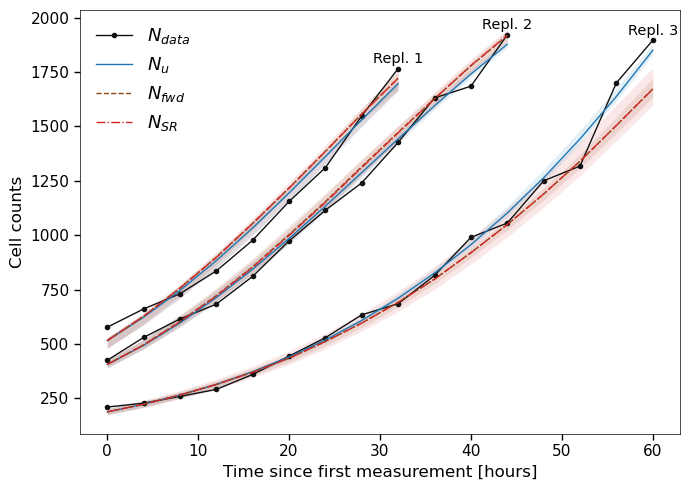

{'2_5': {500: {'key': '2_5',
   'es_val': 500,
   'species_label': 'green',
   'hoursRange': array([24., 28., 32., 36., 40., 44., 48., 52., 56.]),
   'u_true': array([ 577.,  661.,  731.,  836.,  977., 1155., 1311., 1549., 1766.]),
   'u_binn_arr': array([[ 528.9535 ,  634.05634,  753.70874,  887.75085, 1035.6056 ,
           1195.9678 , 1366.2711 , 1542.3292 , 1718.5111 ],
          [ 480.82343,  587.501  ,  710.4052 ,  848.61633, 1000.14795,
           1161.9174 , 1329.7793 , 1498.6973 , 1663.1127 ],
          [ 517.1363 ,  622.5165 ,  743.07355,  878.5561 , 1027.9813 ,
           1189.4266 , 1359.7776 , 1534.6493 , 1708.7313 ],
          [ 529.227  ,  634.843  ,  755.57605,  891.2158 , 1040.757  ,
           1202.1735 , 1372.201  , 1546.2931 , 1718.9342 ],
          [ 521.2724 ,  636.6577 ,  766.95593,  910.0524 , 1062.6991 ,
           1220.611  , 1378.6658 , 1531.3322 , 1673.3965 ]], dtype=float32),
   'u_fwd_arr': array([[ 528.95341   ,  639.48757661,  766.73199841,  906.71732781

In [40]:
analyzer = ForwardSimulationAnalysis(
    keys=keys,
    dataInfo_dict=dataInfo_dict,
    dataObj_dict=dataObj_dict,
    speciesLabels=speciesLabels,
    binn_ES_list=[500],
    binn_models_dics_ES=binn_models_dics_ES,
    binn_exts=binn_exts,
    binnSplitSeeds=binnSplitSeeds,
    init_type=init_type,
    save_dir=save_path1,
    save_dir2=None,
    device=SR_device,
    fig_size=(7, 5),
    legend_config=LegendConfig(fontsize=13, ncols=1),
    counts_log_scale=False,
    xlabel_fontsize=12,
    ylabel_fontsize=12,
    xtick_labelsize=11,
    ytick_labelsize=11,
    title_fontsize=11,
    annotation_fontsize=10.5,
    major_tick_length=4.0,
    major_tick_width=1.0,
    minor_tick_length=2.5,
    minor_tick_width=0.8,
    sr_save_params={
        "population_size": SR_pop_size,
        "niter": SR_niter,
        "percentiles": SR_percentiles,
        "density_scaling": SR_density_scaling,
        "y_scaling": SR_yscaling,
        "use_sf_for_predictions": SR_use_sf,
        "seeds": list(SR_seeds),
        "loss": SR_loss,
        "unary_operators": SR_unary_ops,
        "binary_operators": SR_binary_ops,
        "constraints": SR_constraints,
        "maxsize": SR_max_size,
        "parsimony": SR_parsimony,
        "model_selection": SR_model_selection,
        "save_suffix": "updated_mean",
        "verbose": SR_verbose,
    },
    base_dir=FWD_OUTPUT_DIR,
    base_dir_SR=os.path.join(FWD_OUTPUT_DIR, "sr"),
    shift_time_to_zero=True
)

analyzer.run(
    include_sr=True,
    plot_types=["all_keys_counts"]
)